In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src" / "obgeneration").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from obgeneration.model import occupancy, lighting, hvac, equipment
from obgeneration.model.occupant_profile import Occupant
from obgeneration.generator import occupancy_generator, lighting_generator, hvac_generator, equipment_generator
from obgeneration.generator.ob_utils import ScheduleUtils


RESOLUTION_MINS = 60
RANDOM_SEED = 42


In [2]:
joint_profile_json = """
{
  "occupancy": {
    "num_occupants": 4,
    "household_composition": {
      "occupants": [
        {"weekday_cluster": "long_day_away", "weekend_cluster": "mostly_home"},
        {"weekday_cluster": "long_day_away", "weekend_cluster": "mostly_home"},
        {"weekday_cluster": "morning_away", "weekend_cluster": "mostly_home"},
        {"weekday_cluster": "morning_away", "weekend_cluster": "morning_away"}
      ]
    }
  },
  "lighting": {
    "if_led": true,
    "when_away": true,
    "when_daylight_bright": true
  },
  "equipment": {
    "laundry": {
      "has_washer": true,
      "washer_efficient": true,
      "has_dryer": true,
      "dryer_efficient": false,
      "usage_frequency_per_week": {
        "min": 2,
        "max": 4
      }
    },
    "refrigerator": {
      "has_refrigerator": true,
      "efficient_refrigerator": false,
      "number_of_refrigerators": 1
    },
    "dishwasher": {
      "has_dishwasher": true,
      "dishwasher_efficient": true,
      "dishwashing_operational_logic": {
        "pattern_type": "daily_batch_if_cooked",
        "usage_frequency_per_week": null
      }
    },
    "cooking_products": {
      "has_cooking_products": true,
      "cooking_products_fuel": "electric",
      "usage_frequency_per_week": {
        "min": 5,
        "max": 15
      }
    }
  },
  "hvac": {
    "heating": {
      "type": "thermostat",
      "active_setpoint": 21,
      "sleep_setpoint": 16,
      "absent_setpoint": 16
    },
    "cooling": {
      "type": "thermostat",
      "active_setpoint": 25,
      "sleep_setpoint": 25,
      "absent_setpoint": 45
    }
  },
  "window": {}
}
"""

occupant = Occupant.model_validate_json(joint_profile_json)
joint_profile = json.loads(joint_profile_json)

occ_json = json.dumps(joint_profile["occupancy"], indent=2)
lighting_json = json.dumps(joint_profile["lighting"], indent=2)
eqp_json = json.dumps(joint_profile["equipment"], indent=2)
hvac_json = json.dumps(joint_profile["hvac"], indent=2)
window_json = json.dumps(joint_profile["window"], indent=2)

occ = occupant.occupancy
lighting_obj = occupant.lighting
eqp_obj = occupant.equipment
hvac_obj = occupant.hvac

occ_res = occupancy_generator.OccupancyGenerator.generate_with_defaults(
    occ,
    resolution_mins=RESOLUTION_MINS,
    rng=RANDOM_SEED,
)
lighting_res = lighting_generator.LightingGenerator.generate_with_defaults(
    lighting_obj,
    occ_res.occupancy_states,
    rng=RANDOM_SEED,
)
eqp_res = equipment_generator.EquipmentGenerator.generate_with_defaults(
    eqp_obj,
    occ_res.occupancy_states,
    occ.num_occupants,
    resolution_mins=RESOLUTION_MINS,
    rng=RANDOM_SEED,
)
annual_eqp = sum(eqp_res.schedule) * eqp_res.peak_value
hvac_res = hvac_generator.HVACGenerator.generate_with_defaults(
    hvac_obj,
    occ_res.occupancy_states,
)


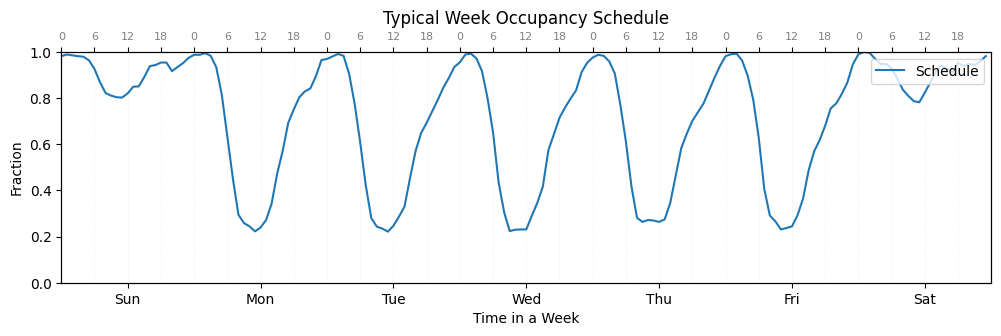

In [3]:
occ_typical_week = ScheduleUtils.get_typical_week_values(occ_res.schedule)
fig = ScheduleUtils.plot_typical_week_schedule(occ_typical_week, title="Typical Week Occupancy Schedule", vmin=0, vmax=1)


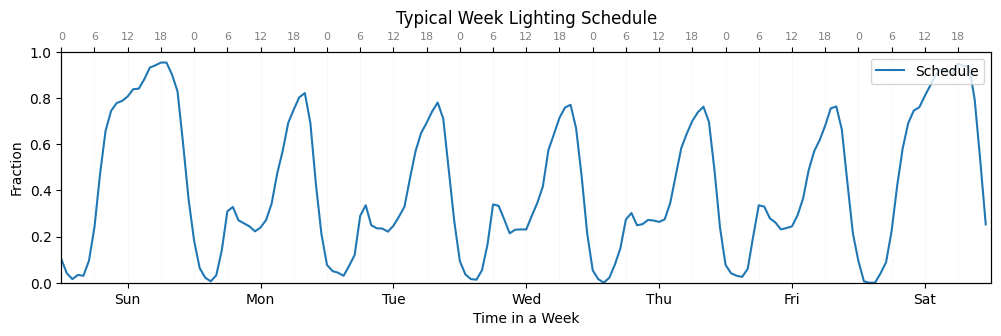

In [4]:
lgt_typical_week = ScheduleUtils.get_typical_week_values(lighting_res.schedule)
fig = ScheduleUtils.plot_typical_week_schedule(lgt_typical_week, title="Typical Week Lighting Schedule", vmin=0, vmax=1)


5228.942365607525
41.8315389248602
3963.785687490174


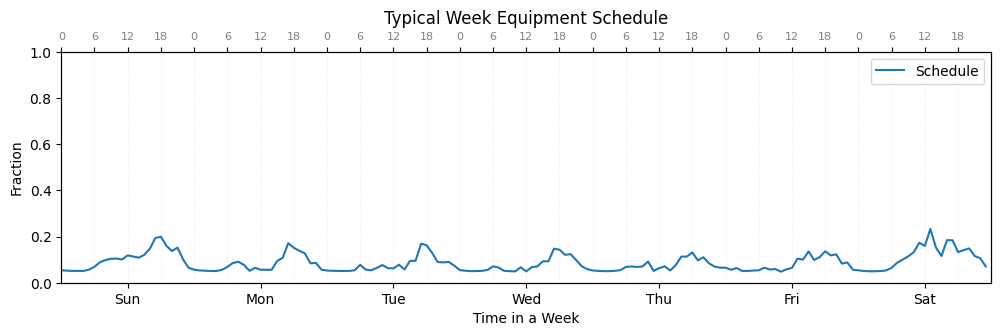

In [5]:
print(eqp_res.peak_value)
print(eqp_res.peak_value / 125)
print(annual_eqp / 1000)
eqp_typical_week = ScheduleUtils.get_typical_week_values(eqp_res.schedule)
fig = ScheduleUtils.plot_typical_week_schedule(eqp_typical_week, title="Typical Week Equipment Schedule", vmin=0, vmax=1)

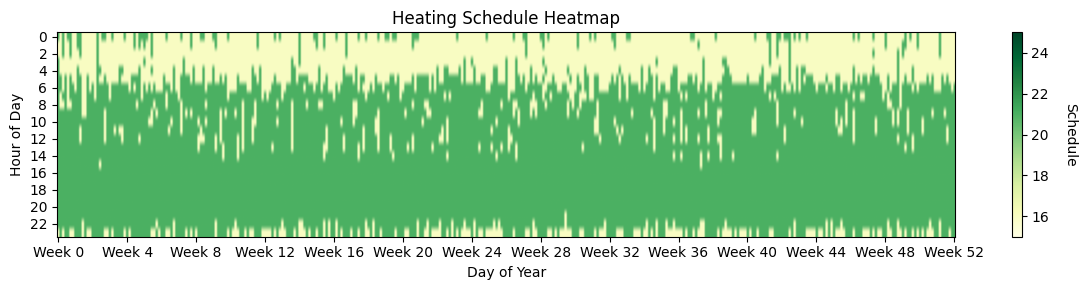

In [6]:
annual_plot = ScheduleUtils.plot_annual_schedule_heatmap(hvac_res.heating.schedule, title="Heating Schedule Heatmap", vmin=15, vmax=25)

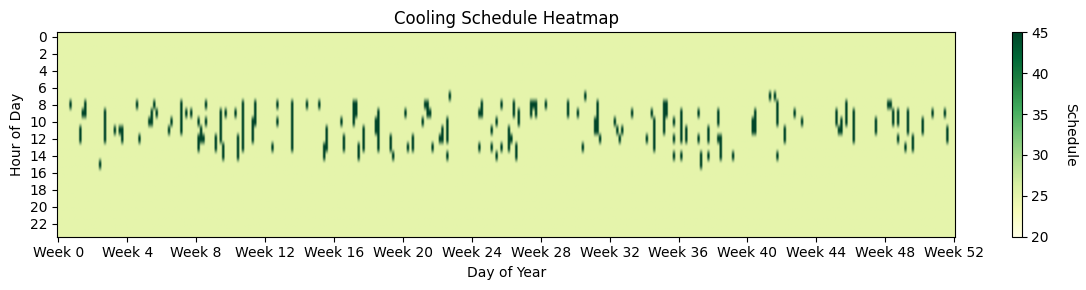

In [7]:
annual_plot = ScheduleUtils.plot_annual_schedule_heatmap(hvac_res.cooling.schedule, title="Cooling Schedule Heatmap", vmin=20, vmax=45)

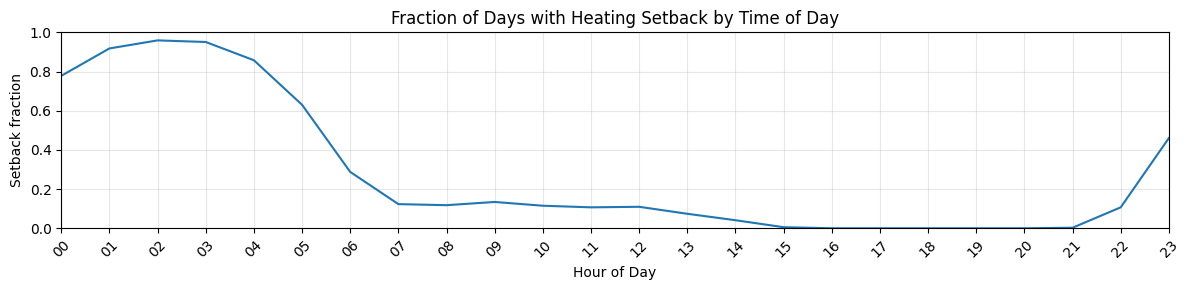

In [8]:
heating_schedule = hvac_res.heating.schedule
schedule = np.array(heating_schedule, dtype=float)
steps_per_day = 24 * 60 // RESOLUTION_MINS
days = len(schedule) // steps_per_day

grid = schedule[:days * steps_per_day].reshape(days, steps_per_day)

active_setpoint = 21.0
setback_mask = grid < active_setpoint
setback_fraction_by_hour = setback_mask.mean(axis=0)

hours = np.arange(steps_per_day) * RESOLUTION_MINS / 60

plt.figure(figsize=(12, 3))
plt.plot(hours, setback_fraction_by_hour)
plt.title("Fraction of Days with Heating Setback by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Setback fraction")
plt.xticks(np.arange(0, 24, 1), [f"{h:02d}" for h in range(24)], rotation=45)
plt.xlim(0, 23)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


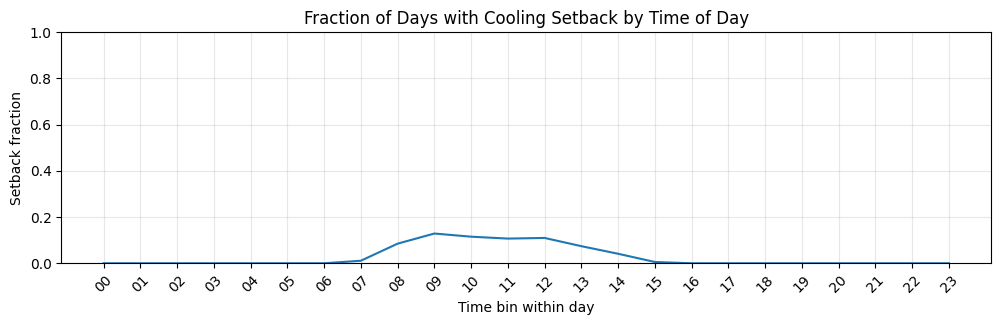

In [9]:
cooling_scheudle = hvac_res.cooling.schedule
schedule = np.array(cooling_scheudle, dtype=float)
steps_per_day = 24 * 60 // RESOLUTION_MINS
days = len(schedule) // steps_per_day

grid = schedule[:days * steps_per_day].reshape(days, steps_per_day)

active_setpoint = 25.0   # adjust to your actual active cooling setpoint
setback_mask = grid > active_setpoint

setback_fraction_by_hour = setback_mask.mean(axis=0)

hours = np.arange(steps_per_day) * RESOLUTION_MINS / 60

plt.figure(figsize=(12, 3))
plt.plot(hours, setback_fraction_by_hour)
plt.title("Fraction of Days with Cooling Setback by Time of Day")
plt.xlabel("Time bin within day")
plt.ylabel("Setback fraction")
plt.xticks(np.arange(0, 24, 1), [f"{h:02d}" for h in range(24)], rotation=45)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()